In [ ]:
# Make this notebook runnable from any working directory: locate the repository
# root by its marker file, then work from this notebook's own folder, which is
# what the relative paths below assume.
import os
from pathlib import Path
_root = Path.cwd().resolve()
while not (_root / "requirements.txt").is_file() and _root != _root.parent:
    _root = _root.parent
_here = _root / "refinement-per-claim" / "safety_metrics"
if not _here.is_dir():
    raise RuntimeError(
        "Could not locate " + str(_here) + ". Run this notebook from inside the "
        "cloned repository."
    )
os.chdir(_here)

# Safety Metrics Analysis

Evaluates 4 automated safety metrics on generated Counter-Narratives (CNs), aggregated per KPI.

**Metrics (all address reviewer concern: "toxic, overly aggressive, or might backfire"):**
1. **Toxicity** — Detoxify `original` model; addresses general harmful content (Hanu & Unitary, 2020)
2. **Insult** — Detoxify `original` model; addresses *"overly aggressive"* language (Hanu & Unitary, 2020)
3. **Threat** — Detoxify `original` model; addresses *"might backfire"* — threatening tone (Hanu & Unitary, 2020)
4. **Offensiveness** — `cardiffnlp/twitter-roberta-base-offensive`; Twitter-trained, ideal for 280-char CNs (Barbieri et al., 2020, EMNLP Findings)

**Comparison groups:**
- CONAN human baseline (Chung et al., 2019, ACL)
- MT-CONAN human baseline (Fanton et al., 2021, ACL)
- Initial agent CNs (per KPI)
- Refined agent CNs (per KPI)

# Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu

ROOT = os.path.dirname(os.getcwd())  # project root (one level up from safety_metrics/)
SCORES_CSV    = os.path.join(ROOT, 'safety_metrics', 'cn_scores.csv')
BASELINE_CSV  = os.path.join(ROOT, 'safety_metrics', 'baseline_scores.csv')

METRICS       = ['toxicity', 'insult', 'threat', 'offensiveness']
METRIC_LABELS = ['Toxicity', 'Insult', 'Threat', 'Offensiveness']
KPI_ORDER     = ['Persuasiveness', 'Emotional Engagement', 'Shareability']

# Consistent colour palette
PALETTE = {
    'CONAN':                         '#8BC34A',
    'MT-CONAN':                      '#4CAF50',
    'Initial / Persuasiveness':       '#90CAF9',
    'Initial / Emotional Engagement': '#64B5F6',
    'Initial / Shareability':         '#42A5F5',
    'Refined / Persuasiveness':       '#EF9A9A',
    'Refined / Emotional Engagement': '#E57373',
    'Refined / Shareability':         '#EF5350',
}

# Load Data

In [2]:
gen_df      = pd.read_csv(SCORES_CSV)
baseline_df = pd.read_csv(BASELINE_CSV)

print('Generated CNs:', len(gen_df))
print('  agent_type counts:', gen_df['agent_type'].value_counts().to_dict())
print('  KPI counts:',        gen_df['kpi'].value_counts().to_dict())
print()
print('Baseline CNs:', len(baseline_df))
print('  source counts:', baseline_df['source'].value_counts().to_dict())

Generated CNs: 360
  agent_type counts: {'initial': 180, 'refined': 180}
  KPI counts: {'Persuasiveness': 120, 'Emotional Engagement': 120, 'Shareability': 120}

Baseline CNs: 360
  source counts: {'CONAN': 180, 'MT-CONAN': 180}


# Aggregate Statistics per Group

In [3]:
# --- Build a unified 'group' label for all rows ---
gen_df = gen_df.copy()
gen_df['group'] = (
    gen_df['agent_type'].str.capitalize()
    + ' / '
    + gen_df['kpi']
)

baseline_df = baseline_df.copy()
baseline_df['group'] = baseline_df['source']

all_df = pd.concat(
    [gen_df[['group'] + METRICS], baseline_df[['group'] + METRICS]],
    ignore_index=True,
)

# --- Ordered group list for display ---
GROUP_ORDER = [
    'MT-CONAN',
    'CONAN',
    'Initial / Persuasiveness',
    'Initial / Emotional Engagement',
    'Initial / Shareability',
    'Refined / Persuasiveness',
    'Refined / Emotional Engagement',
    'Refined / Shareability',
]

# --- Summary table ---
summary_rows = []
for group in GROUP_ORDER:
    subset = all_df[all_df['group'] == group]
    row = {'Group': group, 'N': len(subset)}
    for m, label in zip(METRICS, METRIC_LABELS):
        row[label] = f"{subset[m].mean():.3f} ± {subset[m].std():.3f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Group')
summary_df

,N,Toxicity,Insult,Threat,Offensiveness
Group,,,,,
MT-CONAN,180,0.062 ± 0.141,0.006 ± 0.035,0.001 ± 0.003,0.745 ± 0.127
CONAN,180,0.076 ± 0.122,0.004 ± 0.013,0.001 ± 0.001,0.745 ± 0.103
Initial / Persuasiveness,60,0.130 ± 0.172,0.005 ± 0.016,0.004 ± 0.006,0.687 ± 0.135
Initial / Emotional Engagement,60,0.132 ± 0.120,0.003 ± 0.003,0.005 ± 0.006,0.691 ± 0.079
Initial / Shareability,60,0.012 ± 0.020,0.001 ± 0.001,0.000 ± 0.000,0.714 ± 0.121
Refined / Persuasiveness,60,0.060 ± 0.104,0.002 ± 0.004,0.001 ± 0.003,0.720 ± 0.108
Refined / Emotional Engagement,60,0.103 ± 0.123,0.004 ± 0.009,0.002 ± 0.003,0.689 ± 0.080
Refined / Shareability,60,0.020 ± 0.063,0.001 ± 0.002,0.000 ± 0.001,0.767 ± 0.109


# Statistical Tests

**Kruskal–Wallis** — does KPI framing affect safety scores? (refined CNs only, across 3 KPIs)

**Mann–Whitney U** — did refinement change safety vs. initial? (per KPI)

Note on Offensiveness: refined CNs score marginally higher than initial on this metric.
The key comparison is therefore against the CONAN/MT-CONAN baselines, which we expect
to be higher than both, showing our CNs remain within safe levels regardless.

In [4]:
refined_df = gen_df[gen_df['agent_type'] == 'refined']

kruskal_rows = []
for m, label in zip(METRICS, METRIC_LABELS):
    groups = [refined_df[refined_df['kpi'] == kpi][m].values for kpi in KPI_ORDER]
    stat, p = kruskal(*groups)
    kruskal_rows.append({'Metric': label, 'H-statistic': round(stat, 4), 'p-value': round(p, 4)})

kruskal_df = pd.DataFrame(kruskal_rows).set_index('Metric')
print('Kruskal–Wallis test (refined CNs, across 3 KPIs):')
kruskal_df

Kruskal–Wallis test (refined CNs, across 3 KPIs):


,H-statistic,p-value
Metric,,
Toxicity,52.2284,0.0000
Insult,51.7959,0.0000
Threat,42.9858,0.0000
Offensiveness,18.0159,0.0001


In [5]:
# Pairwise Mann-Whitney U: Refined vs Initial per KPI
mw_rows = []
for kpi in KPI_ORDER:
    r = gen_df[(gen_df['agent_type'] == 'refined') & (gen_df['kpi'] == kpi)]
    i = gen_df[(gen_df['agent_type'] == 'initial') & (gen_df['kpi'] == kpi)]
    for m, label in zip(METRICS, METRIC_LABELS):
        stat, p = mannwhitneyu(r[m].values, i[m].values, alternative='two-sided')
        mw_rows.append({
            'KPI': kpi, 'Metric': label,
            'Refined mean': round(r[m].mean(), 4),
            'Initial mean': round(i[m].mean(), 4),
            'U-statistic': round(stat, 1),
            'p-value': round(p, 4),
            'Sig. (p<0.05)': '✓' if p < 0.05 else '',
        })

mw_df = pd.DataFrame(mw_rows)
print('Mann–Whitney U: Refined vs Initial per KPI')
mw_df

Mann–Whitney U: Refined vs Initial per KPI


,KPI,Metric,Refined mean,Initial mean,U-statistic,p-value,Sig. (p<0.05)
0,Persuasiveness,Toxicity,0.0597,0.1295,1215.0,0.0022,✓
1,Persuasiveness,Insult,0.0018,0.0055,1250.0,0.0039,✓
2,Persuasiveness,Threat,0.0014,0.0036,1072.0,0.0001,✓
3,Persuasiveness,Offensiveness,0.7198,0.6866,2115.0,0.0988,
4,Emotional Engagement,Toxicity,0.1029,0.1321,1413.0,0.0425,✓
5,Emotional Engagement,Insult,0.0041,0.0029,1587.0,0.2647,
6,Emotional Engagement,Threat,0.0020,0.0050,1072.0,0.0001,✓
7,Emotional Engagement,Offensiveness,0.6885,0.6907,1768.0,0.8687,
8,Shareability,Toxicity,0.0200,0.0122,1932.0,0.4901,
9,Shareability,Insult,0.0008,0.0006,1875.0,0.6958,


# Visualisations

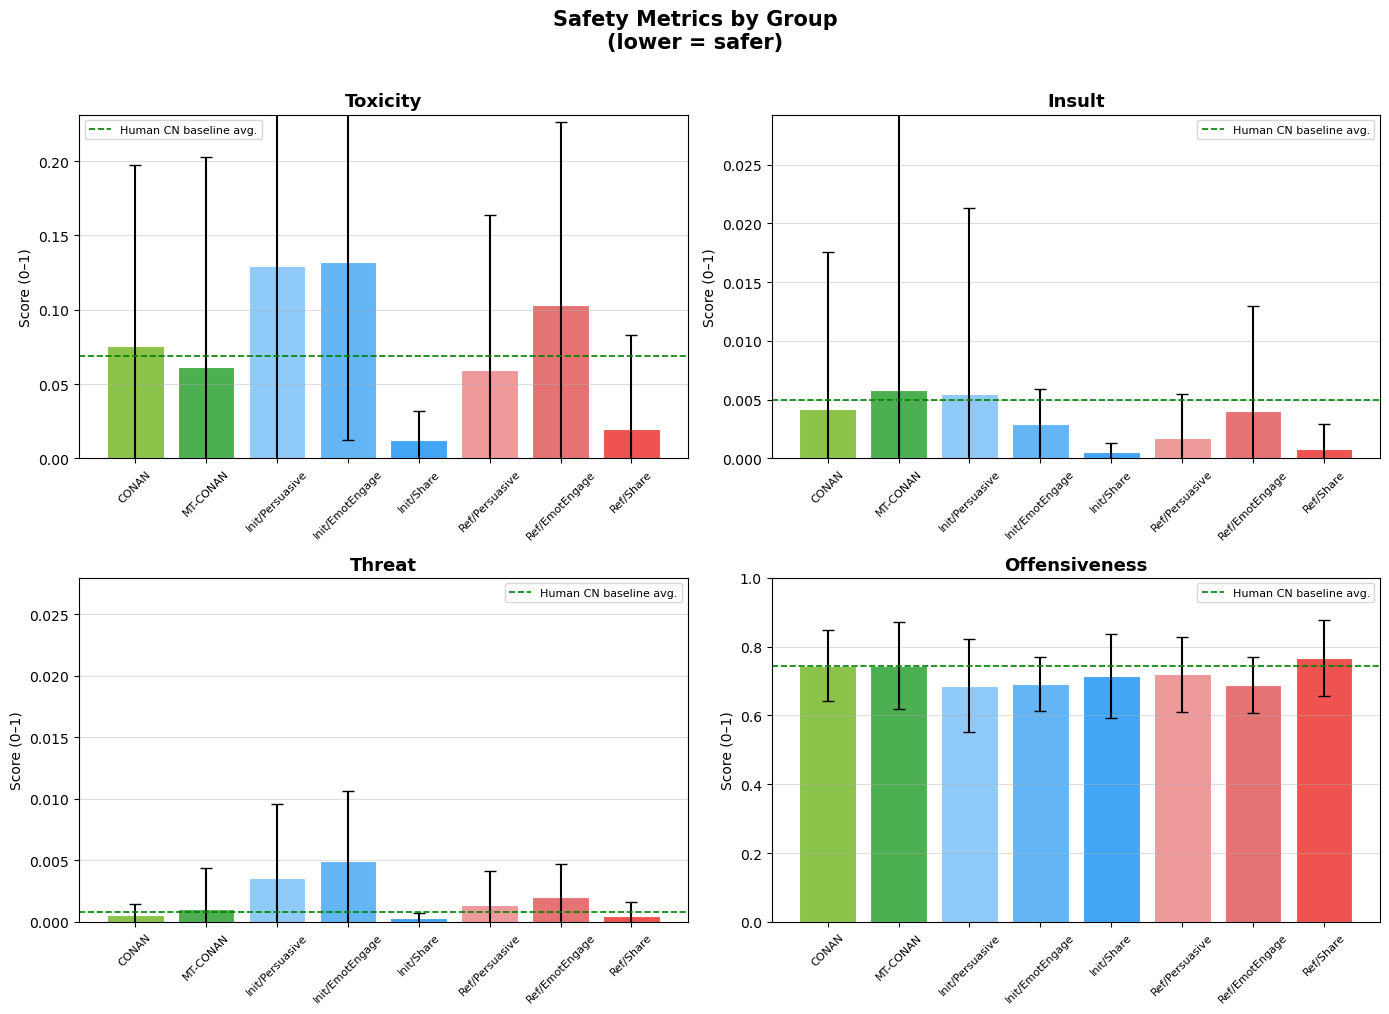

Saved: safety_bar_chart.png


In [6]:
# --- Bar chart: mean score per group per metric ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

GROUP_ORDER_PLOT = [
    'CONAN',
    'MT-CONAN',
    'Initial / Persuasiveness',
    'Initial / Emotional Engagement',
    'Initial / Shareability',
    'Refined / Persuasiveness',
    'Refined / Emotional Engagement',
    'Refined / Shareability',
]

short_labels = [
    g.replace('Initial / ', 'Init/').replace('Refined / ', 'Ref/')
     .replace('Emotional Engagement', 'EmotEngage')
     .replace('Persuasiveness', 'Persuasive')
     .replace('Shareability', 'Share')
    for g in GROUP_ORDER_PLOT
]

for ax, m, label in zip(axes, METRICS, METRIC_LABELS):
    means  = [all_df[all_df['group'] == g][m].mean()  for g in GROUP_ORDER_PLOT]
    errors = [all_df[all_df['group'] == g][m].std()   for g in GROUP_ORDER_PLOT]
    colors = [PALETTE.get(g, '#BDBDBD')               for g in GROUP_ORDER_PLOT]

    ax.bar(short_labels, means, yerr=errors, capsize=4,
           color=colors, edgecolor='white', linewidth=0.8)

    # Reference line: average of the two human baselines
    human_mean = np.mean([
        all_df[all_df['group'] == 'CONAN'][m].mean(),
        all_df[all_df['group'] == 'MT-CONAN'][m].mean(),
    ])
    ax.axhline(human_mean, color='green', linestyle='--', linewidth=1.2,
               label='Human CN baseline avg.')

    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (0–1)', fontsize=10)
    ax.set_ylim(0, min(1.0, max(means) * 1.6 + 0.02))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('Safety Metrics by Group\n(lower = safer)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'safety_metrics', 'safety_bar_chart.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: safety_bar_chart.png')

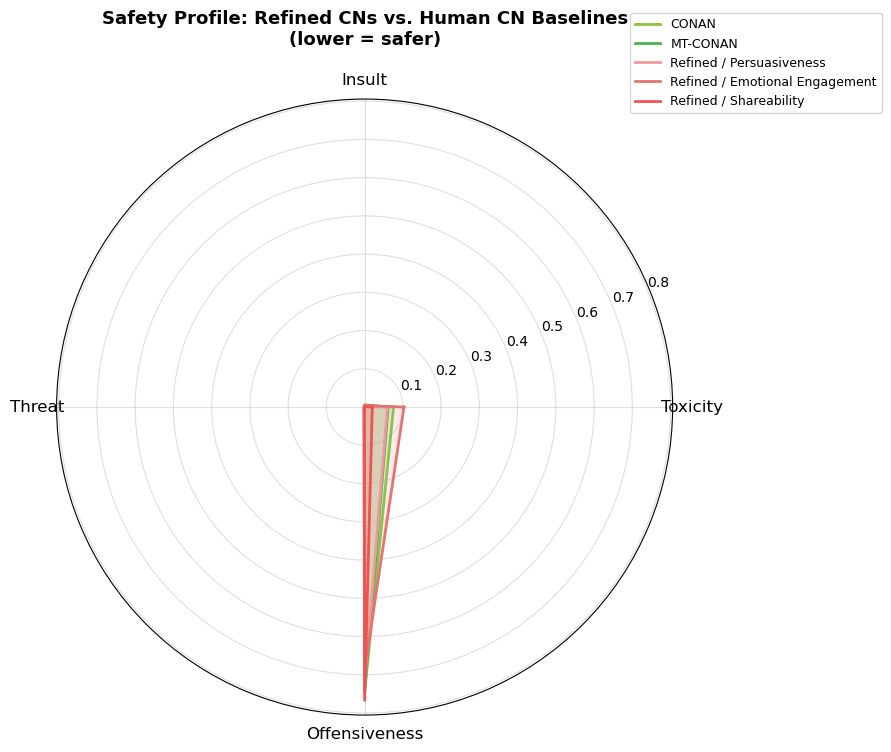

Saved: safety_radar.png


In [7]:
# --- Radar / spider plot: refined KPIs vs human baselines ---
RADAR_GROUPS = [
    'CONAN',
    'MT-CONAN',
    'Refined / Persuasiveness',
    'Refined / Emotional Engagement',
    'Refined / Shareability',
]
RADAR_COLORS = [PALETTE[g] for g in RADAR_GROUPS]

N = len(METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for group, color in zip(RADAR_GROUPS, RADAR_COLORS):
    subset = all_df[all_df['group'] == group]
    values = [subset[m].mean() for m in METRICS] + [subset[METRICS[0]].mean()]
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid', label=group)
    ax.fill(angles, values, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(METRIC_LABELS, fontsize=12)
ax.set_title('Safety Profile: Refined CNs vs. Human CN Baselines\n(lower = safer)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(True, alpha=0.4)

plt.savefig(os.path.join(ROOT, 'safety_metrics', 'safety_radar.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: safety_radar.png')

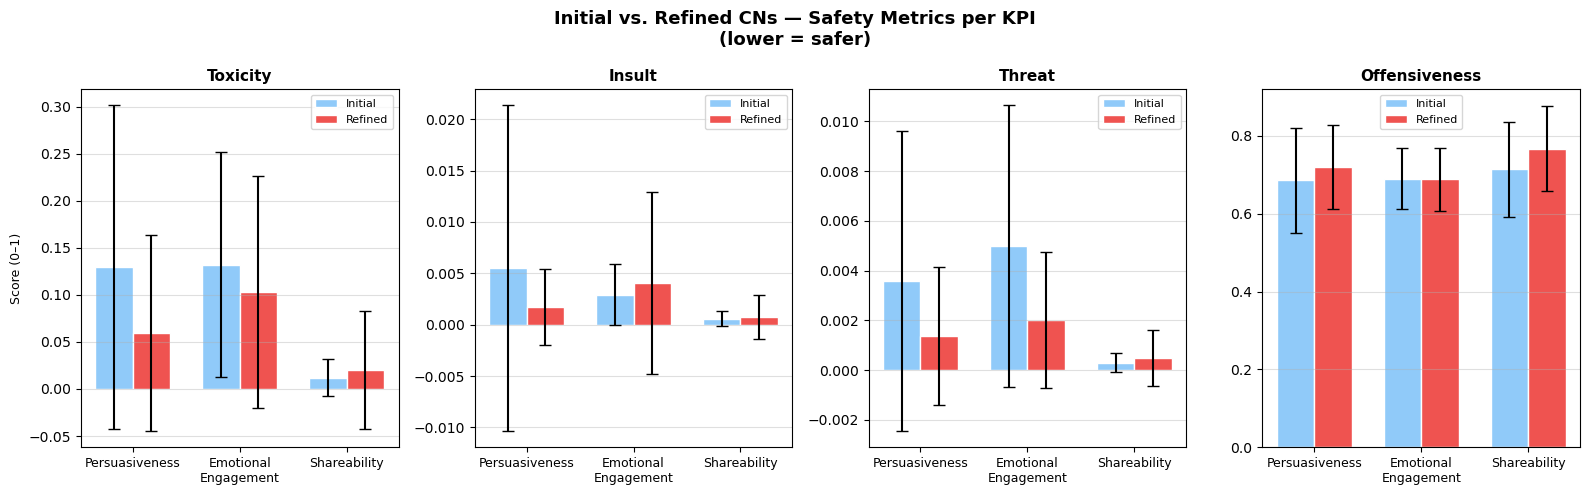

Saved: refined_vs_initial.png


In [8]:
# --- Grouped bar chart: Refined vs Initial per KPI per metric ---
fig, axes = plt.subplots(1, len(METRICS), figsize=(16, 5), sharey=False)

x = np.arange(len(KPI_ORDER))
width = 0.35

for ax, m, label in zip(axes, METRICS, METRIC_LABELS):
    initial_means  = [gen_df[(gen_df['agent_type']=='initial')  & (gen_df['kpi']==k)][m].mean() for k in KPI_ORDER]
    refined_means  = [gen_df[(gen_df['agent_type']=='refined')  & (gen_df['kpi']==k)][m].mean() for k in KPI_ORDER]
    initial_stds   = [gen_df[(gen_df['agent_type']=='initial')  & (gen_df['kpi']==k)][m].std()  for k in KPI_ORDER]
    refined_stds   = [gen_df[(gen_df['agent_type']=='refined')  & (gen_df['kpi']==k)][m].std()  for k in KPI_ORDER]

    ax.bar(x - width/2, initial_means, width, yerr=initial_stds, capsize=4,
           label='Initial', color='#90CAF9', edgecolor='white')
    ax.bar(x + width/2, refined_means, width, yerr=refined_stds, capsize=4,
           label='Refined', color='#EF5350', edgecolor='white')

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(
        [k.replace(' ', '\n') for k in KPI_ORDER], fontsize=9
    )
    ax.set_ylabel('Score (0–1)' if ax == axes[0] else '', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('Initial vs. Refined CNs — Safety Metrics per KPI\n(lower = safer)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'safety_metrics', 'refined_vs_initial.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: refined_vs_initial.png')